# 02 — Exploratory Data Analysis (EDA)
**Goal:** Understand the dataset visually — emotion distribution, waveforms, spectrograms, and MFCC heatmaps.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='darkgrid')
EMOTION_COLORS = {
    'neutral': '#7f8c8d',
    'happy':   '#f1c40f',
    'sad':     '#3498db',
    'angry':   '#e74c3c',
    'fear':    '#9b59b6',
    'disgust': '#27ae60',
    'surprise':'#e67e22'
}
EMOTIONS = list(EMOTION_COLORS.keys())
print('Imports done.')

Imports done.


## 2. Load dataset.csv

In [2]:
df = pd.read_csv('dataset.csv')
print(f'Total samples: {len(df)}')
print(f'Columns: {list(df.columns)}')
df.head()

Total samples: 4240
Columns: ['path', 'emotion', 'source']


,path,emotion,source
0,D:\Projects\CSE445\speech_emotion_recognation\...,neutral,RAVDESS
1,D:\Projects\CSE445\speech_emotion_recognation\...,neutral,RAVDESS
2,D:\Projects\CSE445\speech_emotion_recognation\...,neutral,RAVDESS
3,D:\Projects\CSE445\speech_emotion_recognation\...,neutral,RAVDESS
4,D:\Projects\CSE445\speech_emotion_recognation\...,neutral,RAVDESS


## 3. Emotion Distribution

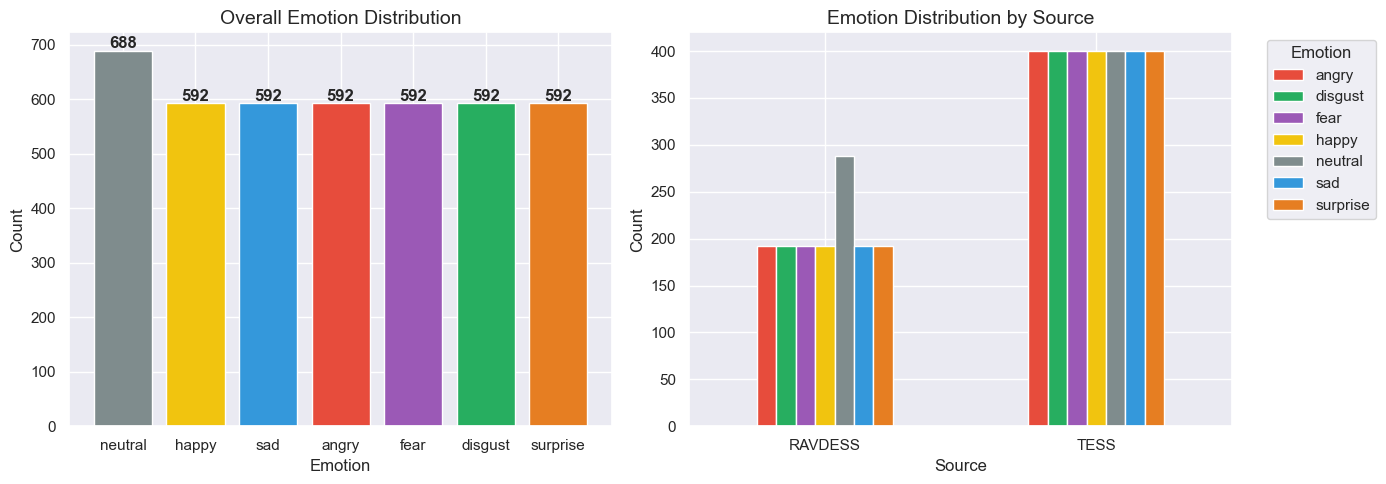

Saved: eda_emotion_distribution.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
emotion_counts = df['emotion'].value_counts().reindex(EMOTIONS)
axes[0].bar(emotion_counts.index, emotion_counts.values,
            color=[EMOTION_COLORS[e] for e in emotion_counts.index])
axes[0].set_title('Overall Emotion Distribution', fontsize=14)
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
for i, v in enumerate(emotion_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Distribution by source
source_emotion = df.groupby(['source', 'emotion']).size().unstack(fill_value=0)
source_emotion.plot(kind='bar', ax=axes[1],
                    color=[EMOTION_COLORS[e] for e in source_emotion.columns])
axes[1].set_title('Emotion Distribution by Source', fontsize=14)
axes[1].set_xlabel('Source')
axes[1].set_ylabel('Count')
axes[1].legend(title='Emotion', bbox_to_anchor=(1.05, 1))
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_emotion_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_emotion_distribution.png')

## 4. Waveform Plot — One Sample Per Emotion

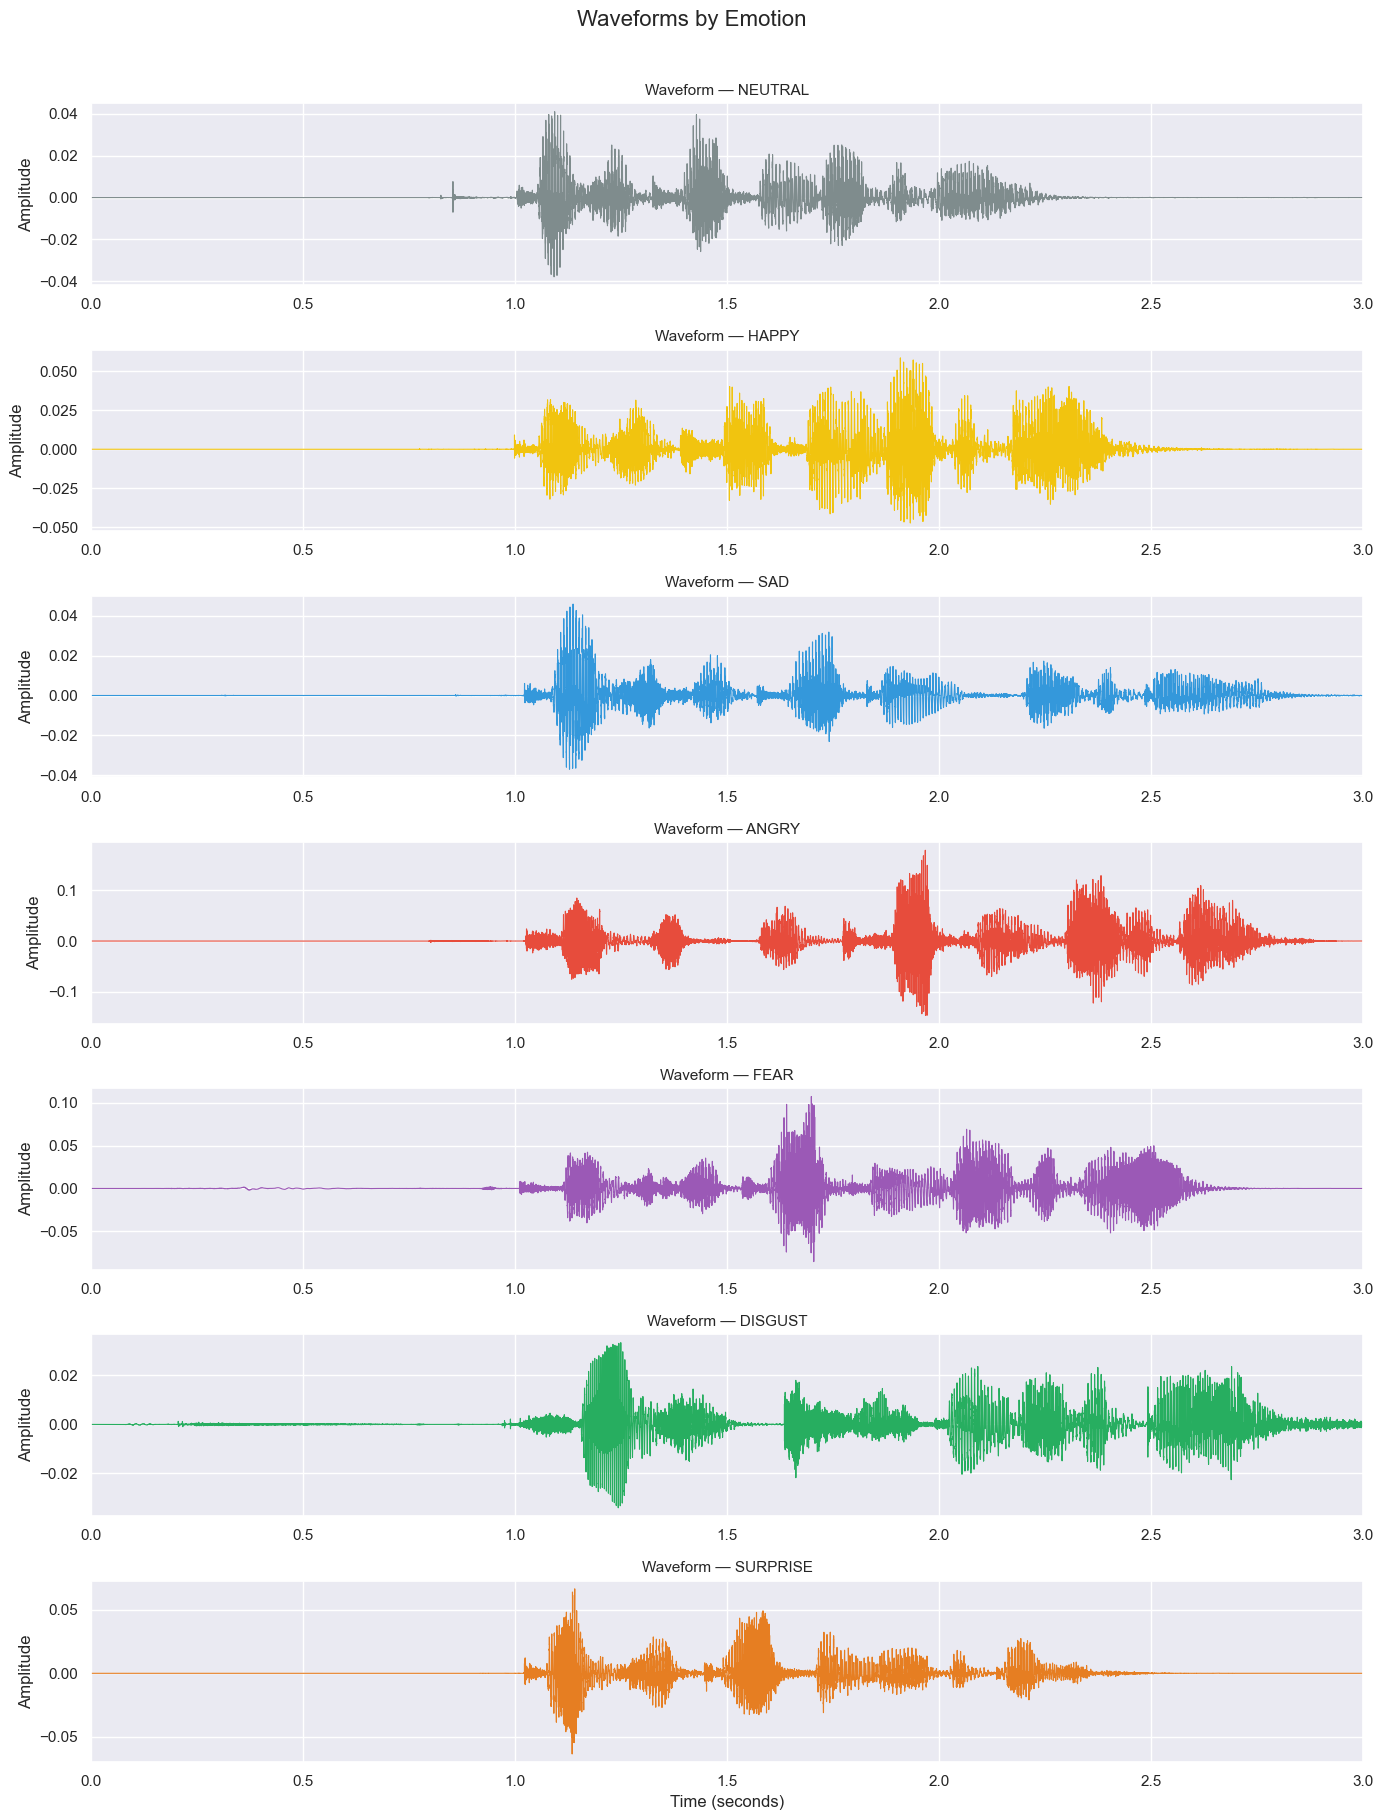

Saved: eda_waveforms.png


In [4]:
fig, axes = plt.subplots(7, 1, figsize=(14, 18))

for i, emotion in enumerate(EMOTIONS):
    sample_path = df[df['emotion'] == emotion].iloc[0]['path']
    y, sr = librosa.load(sample_path, duration=3)
    axes[i].plot(np.linspace(0, 3, len(y)), y,
                 color=EMOTION_COLORS[emotion], linewidth=0.8)
    axes[i].set_title(f'Waveform — {emotion.upper()}', fontsize=11)
    axes[i].set_ylabel('Amplitude')
    axes[i].set_xlim([0, 3])

axes[-1].set_xlabel('Time (seconds)')
plt.suptitle('Waveforms by Emotion', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('eda_waveforms.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_waveforms.png')

## 5. Spectrogram Plot — One Sample Per Emotion

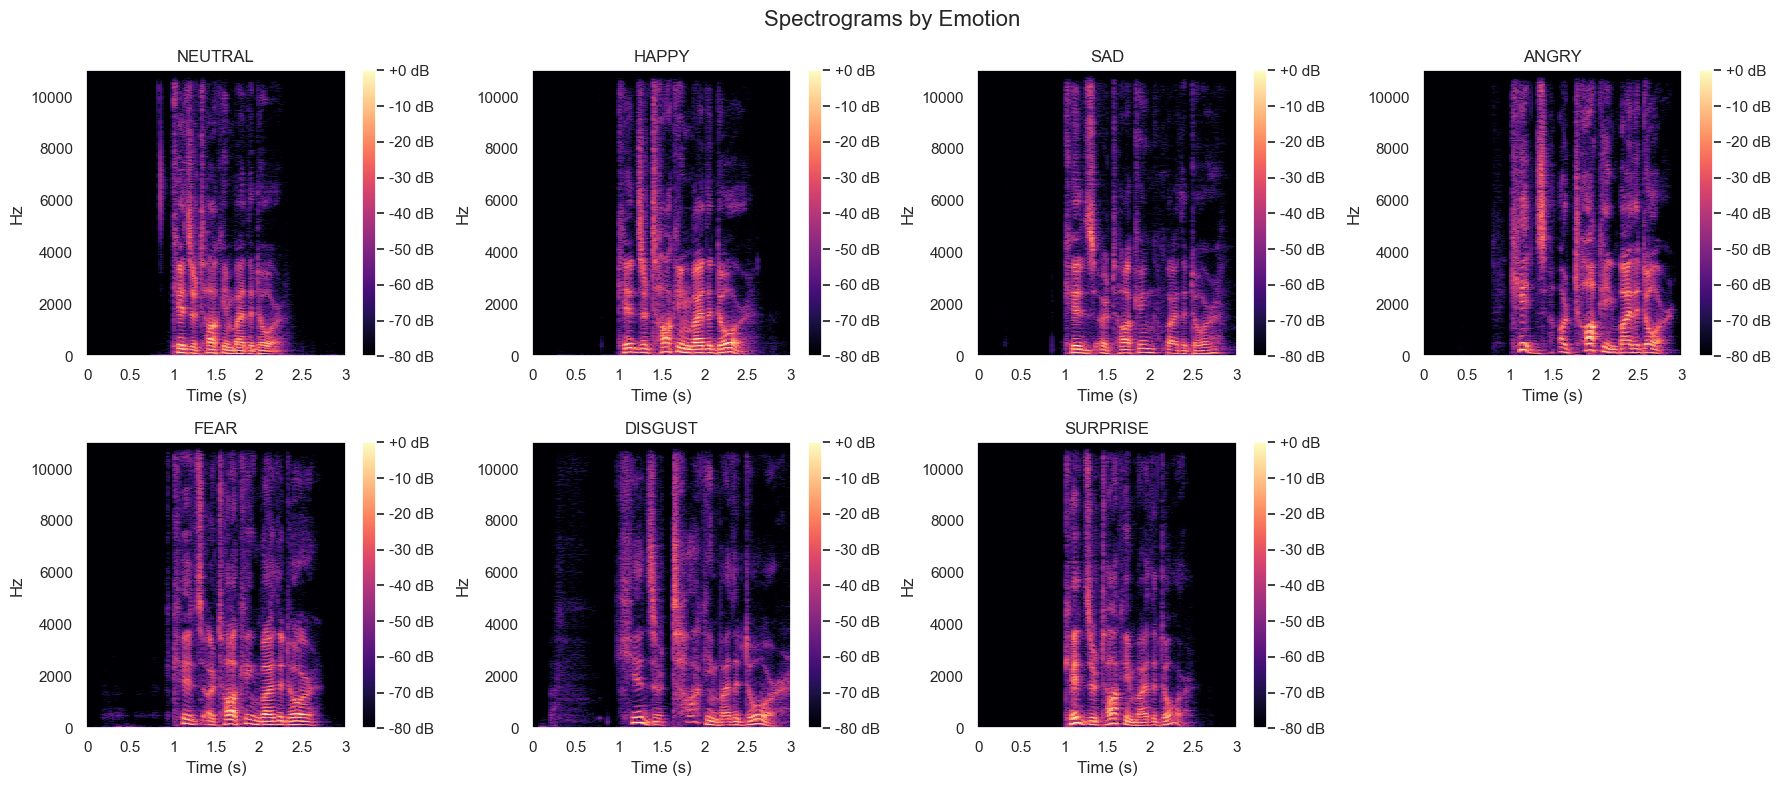

Saved: eda_spectrograms.png


In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, emotion in enumerate(EMOTIONS):
    sample_path = df[df['emotion'] == emotion].iloc[0]['path']
    y, sr = librosa.load(sample_path, duration=3)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=axes[i])
    axes[i].set_title(f'{emotion.upper()}', fontsize=12)
    axes[i].set_xlabel('Time (s)')
    axes[i].set_ylabel('Hz')
    fig.colorbar(img, ax=axes[i], format='%+2.0f dB')

# Hide the last empty subplot
axes[-1].set_visible(False)

plt.suptitle('Spectrograms by Emotion', fontsize=16)
plt.tight_layout()
plt.savefig('eda_spectrograms.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_spectrograms.png')

## 6. MFCC Heatmap — One Sample Per Emotion

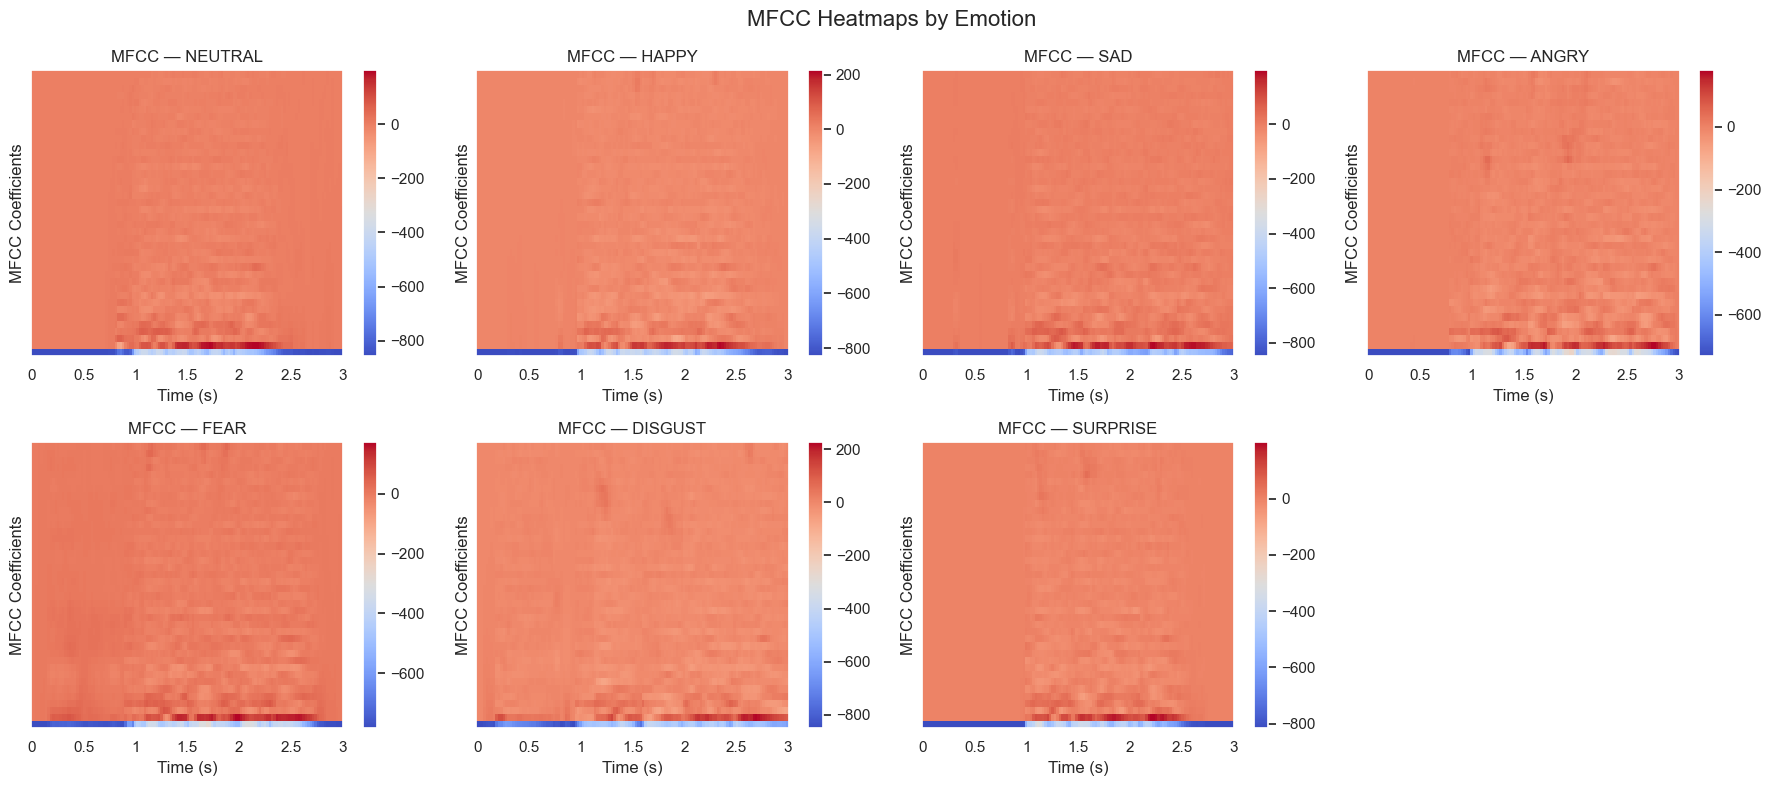

Saved: eda_mfcc_heatmaps.png


In [6]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, emotion in enumerate(EMOTIONS):
    sample_path = df[df['emotion'] == emotion].iloc[0]['path']
    y, sr = librosa.load(sample_path, duration=3)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    img = librosa.display.specshow(mfcc, x_axis='time', ax=axes[i])
    axes[i].set_title(f'MFCC — {emotion.upper()}', fontsize=12)
    axes[i].set_xlabel('Time (s)')
    axes[i].set_ylabel('MFCC Coefficients')
    fig.colorbar(img, ax=axes[i])

axes[-1].set_visible(False)

plt.suptitle('MFCC Heatmaps by Emotion', fontsize=16)
plt.tight_layout()
plt.savefig('eda_mfcc_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_mfcc_heatmaps.png')

## 7. Audio Duration Analysis

Calculating audio durations (this may take a minute)...


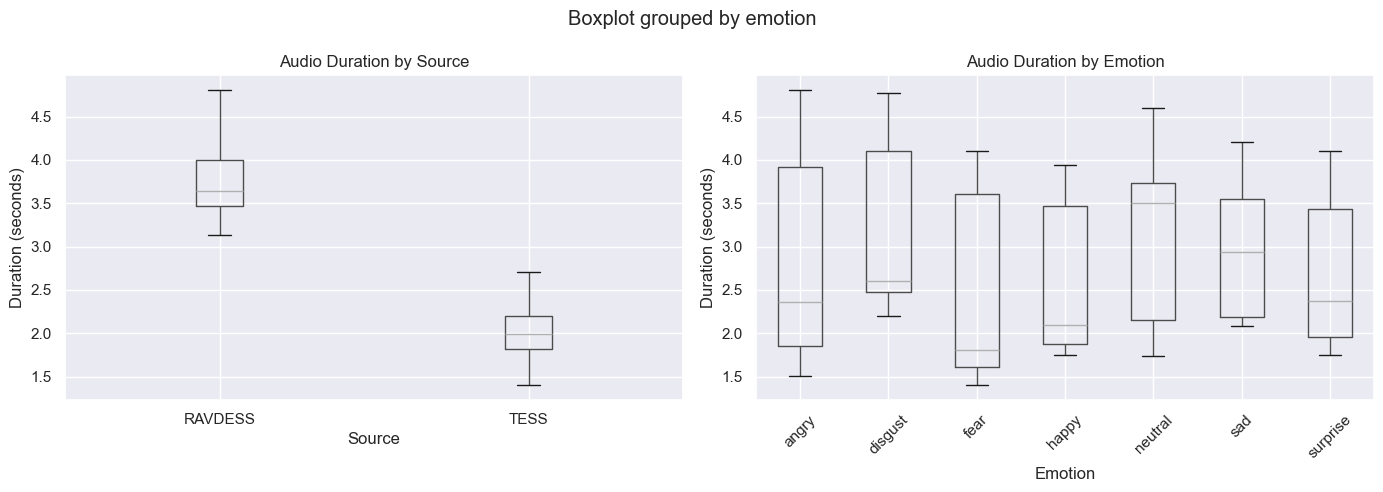


Average duration by source:
source
RAVDESS    3.74
TESS       2.02


In [7]:
print('Calculating audio durations (this may take a minute)...')

# Sample 100 files per source for speed
sample_df = df.groupby('source').apply(lambda x: x.sample(100, random_state=42)).reset_index(drop=True)

durations = []
for _, row in sample_df.iterrows():
    try:
        duration = librosa.get_duration(path=row['path'])
        durations.append({'source': row['source'], 'emotion': row['emotion'], 'duration': duration})
    except:
        pass

dur_df = pd.DataFrame(durations)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Duration by source
dur_df.boxplot(column='duration', by='source', ax=axes[0])
axes[0].set_title('Audio Duration by Source')
axes[0].set_xlabel('Source')
axes[0].set_ylabel('Duration (seconds)')

# Duration by emotion
dur_df.boxplot(column='duration', by='emotion', ax=axes[1])
axes[1].set_title('Audio Duration by Emotion')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Duration (seconds)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_durations.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAverage duration by source:")
print(dur_df.groupby('source')['duration'].mean().round(2).to_string())

---
**Done!** EDA complete. 4 plots saved. Next step → `03_feature_extraction.ipynb`